# 08 · Nexus RecSys — Métricas de Negocio, ROI y Mejoras de Modelos

**Sistema de Recomendación E-Commerce · RetailRocket Dataset**

---

Este notebook implementa las mejoras al modelo base de `07_modeling.ipynb`:

| Paso | Contenido |
|------|-----------|
| 1 | Carga de datos y reconstrucción del split temporal |
| 2 | Framework extendido: métricas estándar + **ROI de negocio** |
| 3 | Baseline: SVD Optimizado (cargado desde artefactos del notebook 07) |
| 4 | **Mejora A**: Temporal Decay — ponderación por recencia |
| 5 | **Mejora B**: IPS Debiasing — corrección de sesgo de popularidad |
| 6 | **Mejora C**: Híbrido Adaptativo — alpha dinámico según historial |
| 7 | Comparación completa con métricas estándar + ROI |
| 8 | **Análisis ROI de Negocio**: Revenue@K, Conversion Lift, CTR |
| 9 | Análisis de Segmentos: cold-start vs usuarios warm (Fairness Audit) |
| 10 | Guardado de artefactos actualizados |

### Por qué estas mejoras (justificación técnica)

| Propuesta original | Decisión | Motivo |
|--------------------|----------|--------|
| Two-tower Neural | ❌ Descartada | PyTorch/TF sin soporte estable en Python 3.13 |
| ALS con `implicit` | ❌ Descartada | Sin wheel para Python 3.13; SVD con `alpha_conf` ya aproxima ALS |
| NCF / GRU4Rec | ❌ Descartada | Deep learning ineficiente en sparsity 99.9994% |
| IPS Debiasing | ✅ Implementada | Factible con numpy/scipy; mejora Coverage y Novelty |
| Fairness audit | ✅ Implementada | Análisis de segmentos cold vs warm |
| **Temporal Decay** *(nueva)* | ✅ Implementada | No estaba en la lista; mejora NDCG ~10-15% |
| **Híbrido Adaptativo** *(nueva)* | ✅ Implementada | El híbrido fijo pierde frente a SVD (bug); alpha dinámico lo corrige |
| **ROI Business Metrics** | ✅ Implementada | Pedido explícito: Revenue@K, CTR@K, ConversionLift@K |

> **Reproducibilidad:** `random_state=42` fijado en todos los pasos.
> Requiere ejecutar `07_modeling.ipynb` primero (genera `encoders/final_model.pkl`).

## 0 · Setup y Configuración Global

In [1]:
import os, time, json, pickle, warnings, logging
from pathlib import Path

import numpy as np
import pandas as pd
import scipy.sparse as sp
from scipy.sparse.linalg import svds
from sklearn.preprocessing import normalize as skl_normalize

import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
logging.getLogger("lightgbm").setLevel(logging.ERROR)

# ── Semillas reproducibles ─────────────────────────────────────────────────────
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# ── Parámetros globales ────────────────────────────────────────────────────────
CUTOFF_DATE    = pd.Timestamp("2015-08-22", tz="UTC")
K_VALUES       = [5, 10]
N_EVAL_USERS   = 3_000
DECAY_LAMBDA   = 0.03       # vida media ~= ln(2)/0.03 ~= 23 días
IPS_POWER      = 0.4        # suavizado IPS (0=sin corrección, 1=corrección máxima)
ALPHA_BY_HIST  = {          # alpha adaptativo: mayor alpha = más SVD, menos CB
    1: 0.25,                #  ≤1 ítem (cold): más contenido
    4: 0.60,                #  2-4 ítems: balance
    999999: 0.88            #  5+ ítems (warm): más SVD
}

# ── Parámetros del caso de negocio ────────────────────────────────────────────
N_DAILY_ACTIVE_USERS = 50_000      # usuarios activos/día (estimado)
AVG_TICKET_USD       = 45.0        # ticket promedio e-commerce (USD)

# ── Rutas ──────────────────────────────────────────────────────────────────────
HERE      = Path().resolve()
ROOT      = HERE.parent if (HERE.parent / "data").exists() else HERE
DATA_DIR  = ROOT / "data" / "processed"
ENC_DIR   = ROOT / "encoders"
DOCS_DIR  = ROOT / "docs"
DOCS_DIR.mkdir(exist_ok=True)

sns.set_theme(style="whitegrid", palette="muted")

print(f"Proyecto       : {ROOT}")
print(f"Lambda decay   : {DECAY_LAMBDA}  (vida media ~{0.693/DECAY_LAMBDA:.1f} dias)")
print(f"IPS power      : {IPS_POWER}")
print(f"alfa cold/tepid/warm: {list(ALPHA_BY_HIST.values())}")
print(f"Usuarios act/dia: {N_DAILY_ACTIVE_USERS:,}")
print(f"Ticket promedio : ${AVG_TICKET_USD}")

Proyecto       : C:\Users\Usuario\Desktop\HENRY\PROYECTO FINAL\EDA PRUEBA\nexus-recsys
Lambda decay   : 0.03  (vida media ~23.1 dias)
IPS power      : 0.4
alfa cold/tepid/warm: [0.25, 0.6, 0.88]
Usuarios act/dia: 50,000
Ticket promedio : $45.0


## 1 · Carga de Datos y Reconstrucción del Split Temporal

In [2]:
print("Cargando datos procesados...")
t0 = time.time()

im  = pd.read_csv(DATA_DIR / "interaction_matrix.csv")
itf = pd.read_csv(DATA_DIR / "item_features.csv")

im["last_interaction_ts"] = pd.to_datetime(im["last_interaction_ts"], format="ISO8601", utc=True)

print(f"  interaction_matrix : {im.shape}")
print(f"  item_features      : {itf.shape}")
print(f"  Columnas IM        : {im.columns.tolist()}")
print(f"  Carga en           : {time.time()-t0:.1f}s")
print("\nDistribución de tipos de interacción:")
print(im["last_interaction_type"].value_counts().to_string())

Cargando datos procesados...


  interaction_matrix : (2145179, 7)
  item_features      : (235061, 13)
  Columnas IM        : ['visitorid', 'itemid', 'interaction_strength', 'last_interaction_type', 'n_interactions', 'last_interaction_ts', 'days_since_last']
  Carga en           : 7.6s

Distribución de tipos de interacción:


last_interaction_type
view           2110705
addtocart        28114
transaction       6360


In [3]:
# ── Split temporal ─────────────────────────────────────────────────────────────
train_mask = im["last_interaction_ts"] < CUTOFF_DATE
train_df   = im[train_mask].copy()
test_df    = im[~train_mask].copy()

# ── Warm users (evaluables) ────────────────────────────────────────────────────
train_users_set = set(train_df["visitorid"].unique())
test_users_set  = set(test_df["visitorid"].unique())
warm_users      = sorted(train_users_set & test_users_set)

rng = np.random.default_rng(RANDOM_STATE)
eval_users = rng.choice(warm_users, size=min(N_EVAL_USERS, len(warm_users)),
                        replace=False).tolist()

# ── Estructuras de acceso rápido ──────────────────────────────────────────────
train_items_by_user = train_df.groupby("visitorid")["itemid"].apply(set).to_dict()
test_items_by_user  = test_df.groupby("visitorid")["itemid"].apply(set).to_dict()

# Para métricas ROI: transacciones en test
test_transactions_by_user = (
    test_df[test_df["last_interaction_type"] == "transaction"]
    .groupby("visitorid")["itemid"].apply(set).to_dict()
)
test_addtocart_by_user = (
    test_df[test_df["last_interaction_type"] == "addtocart"]
    .groupby("visitorid")["itemid"].apply(set).to_dict()
)

# ── Catálogo global ───────────────────────────────────────────────────────────
all_items_global = sorted(im["itemid"].unique())
n_items_global   = len(all_items_global)

n_test_buyers  = sum(1 for u in eval_users if test_transactions_by_user.get(u))
n_test_carters = sum(1 for u in eval_users if test_addtocart_by_user.get(u))

print(f"Train interactions  : {len(train_df):>10,}")
print(f"Test  interactions  : {len(test_df):>10,}")
print(f"Warm users total    : {len(warm_users):>10,}")
print(f"Eval sample         : {len(eval_users):>10,}")
print(f"  ─ con compra en test  : {n_test_buyers:>7,}  ({n_test_buyers/len(eval_users)*100:.1f}%)")
print(f"  ─ con carrito en test : {n_test_carters:>7,}  ({n_test_carters/len(eval_users)*100:.1f}%)")
print(f"Catálogo global     : {n_items_global:>10,}")

Train interactions  :  1,763,782
Test  interactions  :    381,397
Warm users total    :     20,577
Eval sample         :      3,000
  ─ con compra en test  :      20  (0.7%)
  ─ con carrito en test :      62  (2.1%)
Catálogo global     :    235,061


In [4]:
# ── Construir matriz dispersa de entrenamiento ─────────────────────────────────
all_train_users = sorted(train_df["visitorid"].unique())
all_train_items = sorted(train_df["itemid"].unique())

user2idx = {u: i for i, u in enumerate(all_train_users)}
item2idx = {it: i for i, it in enumerate(all_train_items)}
idx2user = {i: u for u, i in user2idx.items()}
idx2item = {i: it for it, i in item2idx.items()}

n_train_users = len(all_train_users)
n_train_items = len(all_train_items)

rows_std = train_df["visitorid"].map(user2idx).values
cols_std = train_df["itemid"].map(item2idx).values
vals_std = train_df["interaction_strength"].values.astype(np.float32)

train_matrix = sp.csr_matrix(
    (vals_std, (rows_std, cols_std)),
    shape=(n_train_users, n_train_items),
    dtype=np.float32
)

item_pop_train = train_df.groupby("itemid")["visitorid"].count().rename("pop")
item_pop_dict  = item_pop_train.to_dict()
n_train_total  = int(train_df["visitorid"].count())

INTERACTION_WEIGHTS = {"transaction": 3, "addtocart": 2, "view": 1}
type_weight_lookup = (
    train_df
    .assign(w=train_df["last_interaction_type"].map(INTERACTION_WEIGHTS).fillna(1))
    .set_index(["visitorid", "itemid"])["w"]
    .to_dict()
)

print(f"Matriz train shape  : {train_matrix.shape}")
print(f"Non-zeros           : {train_matrix.nnz:,}")
print(f"Sparsity train      : {1 - train_matrix.nnz/(n_train_users*n_train_items):.6f}")
print("Índices y matriz de entrenamiento construidos.")

Matriz train shape  : (1158463, 215964)
Non-zeros           : 1,763,782
Sparsity train      : 0.999993
Índices y matriz de entrenamiento construidos.


## 2 · Framework de Evaluación: Métricas Estándar + ROI de Negocio

### 2.1 Métricas estándar de ranking

Las mismas de `07_modeling.ipynb`: Precision, Recall, NDCG, MAP, Coverage, Novelty.

### 2.2 Nuevas métricas de negocio / ROI

| Métrica | Fórmula | Interpretación |
|---------|---------|----------------|
| **Revenue@K** | fracción de top-K que el usuario compró en test | P(recomendación → compra) |
| **CTR@K** | fracción de top-K con cualquier interacción en test | Click-Through Rate proxy |
| **ConvLift@K** | Revenue@K / p_baseline | x-veces mejor que mostrar ítems aleatorios |

> **Nota:** El dataset RetailRocket no incluye precios. Se usa `transaction` como
> proxy de revenue = 1 unidad. Con precios reales, `Revenue@K x avg_ticket = ERPI`.

In [5]:
# ── Funciones de métricas estándar ─────────────────────────────────────────────

def precision_at_k(recs, relevant_set, k):
    return len(set(recs[:k]) & relevant_set) / k if k > 0 else 0.0

def recall_at_k(recs, relevant_set, k):
    if not relevant_set:
        return 0.0
    return len(set(recs[:k]) & relevant_set) / len(relevant_set)

def ndcg_at_k(recs, relevant_set, k):
    dcg   = sum(1.0 / np.log2(i + 2) for i, it in enumerate(recs[:k]) if it in relevant_set)
    ideal = sum(1.0 / np.log2(i + 2) for i in range(min(len(relevant_set), k)))
    return dcg / ideal if ideal > 0 else 0.0

def ap_at_k(recs, relevant_set, k):
    if not relevant_set:
        return 0.0
    score, hits = 0.0, 0
    for i, item in enumerate(recs[:k]):
        if item in relevant_set:
            hits += 1
            score += hits / (i + 1)
    return score / min(len(relevant_set), k)

def novelty_score(recs, item_pop_dict, n_train_total):
    scores = [-np.log2(item_pop_dict.get(it, 1) / n_train_total + 1e-10) for it in recs]
    return float(np.mean(scores)) if scores else 0.0

# ── Métricas de negocio / ROI ─────────────────────────────────────────────────

def revenue_at_k(recs, transaction_items, k):
    """Fracción de top-K que el usuario compró en test. Proxy de Revenue."""
    return len(set(recs[:k]) & transaction_items) / k if recs and k > 0 else 0.0

def ctr_at_k(recs, any_test_items, k):
    """Fracción de top-K con cualquier interacción en test. Proxy de CTR."""
    return len(set(recs[:k]) & any_test_items) / k if recs and k > 0 else 0.0

print("Funciones de métricas estándar + ROI definidas.")

Funciones de métricas estándar + ROI definidas.


In [6]:
# ── Calcular baseline de conversión ──────────────────────────────────────────
n_test_transactions_global = len(test_df[test_df["last_interaction_type"] == "transaction"])
baseline_conversion_rate   = n_test_transactions_global / (len(test_users_set) * n_items_global)

upper_bound_rev10 = np.mean([
    min(len(test_transactions_by_user.get(u, set())), 10) / 10
    for u in eval_users
])

print(f"Transacciones test (total)     : {n_test_transactions_global:>10,}")
print(f"Baseline P(compra|aleatorio)   : {baseline_conversion_rate:.2e}")
print(f"% usuarios eval con compra     : {n_test_buyers/len(eval_users)*100:.1f}%")
print(f"Revenue@10 upper bound (perf.) : {upper_bound_rev10:.4f}")
print()
print(f"Interpretación del ConvLift:")
print(f"  Si Revenue@10 = 0.005 y baseline = {baseline_conversion_rate:.2e}:")
print(f"  Lift = 0.005 / {baseline_conversion_rate:.2e} = {0.005/max(baseline_conversion_rate,1e-12):.0f}x")

Transacciones test (total)     :      1,208
Baseline P(compra|aleatorio)   : 1.91e-08
% usuarios eval con compra     : 0.7%
Revenue@10 upper bound (perf.) : 0.0008

Interpretación del ConvLift:
  Si Revenue@10 = 0.005 y baseline = 1.91e-08:
  Lift = 0.005 / 1.91e-08 = 262395x


In [7]:
# ── Función centralizada de evaluación extendida ──────────────────────────────

def evaluate_model_extended(
    get_recs_fn, eval_user_ids,
    test_items_by_user, train_items_by_user,
    test_transactions_by_user,
    item_pop_dict, n_train_total, catalog_size,
    baseline_conversion_rate,
    k_values=[5, 10]
):
    """
    Evaluación extendida: métricas de ranking estándar + métricas de negocio/ROI.

    ROI metrics
    -----------
    Revenue@K  : fracción de top-K que el usuario compró en test (proxy revenue)
    CTR@K      : fracción de top-K con cualquier interacción en test
    ConvLift@K : Revenue@K / baseline_conversion_rate
    """
    keys  = ["p", "r", "ndcg", "map", "rev", "ctr"]
    accum = {k: {m: [] for m in keys} for k in k_values}
    all_recommended = set()
    n_evaluated = 0

    for uid in eval_user_ids:
        test_items  = test_items_by_user.get(uid, set())
        if not test_items:
            continue
        trans_items = test_transactions_by_user.get(uid, set())
        max_k       = max(k_values)
        try:
            recs = get_recs_fn(uid, max_k)
        except Exception:
            continue
        all_recommended.update(recs)
        n_evaluated += 1
        for k in k_values:
            accum[k]["p"].append(precision_at_k(recs, test_items, k))
            accum[k]["r"].append(recall_at_k(recs, test_items, k))
            accum[k]["ndcg"].append(ndcg_at_k(recs, test_items, k))
            accum[k]["map"].append(ap_at_k(recs, test_items, k))
            accum[k]["rev"].append(revenue_at_k(recs, trans_items, k))
            accum[k]["ctr"].append(ctr_at_k(recs, test_items, k))

    metrics = {"n_evaluated": n_evaluated}
    for k in k_values:
        if accum[k]["p"]:
            metrics[f"Precision@{k}"] = float(np.mean(accum[k]["p"]))
            metrics[f"Recall@{k}"]    = float(np.mean(accum[k]["r"]))
            metrics[f"NDCG@{k}"]      = float(np.mean(accum[k]["ndcg"]))
            metrics[f"MAP@{k}"]       = float(np.mean(accum[k]["map"]))
            metrics[f"Revenue@{k}"]   = float(np.mean(accum[k]["rev"]))
            metrics[f"CTR@{k}"]       = float(np.mean(accum[k]["ctr"]))
            rev_mean                  = metrics[f"Revenue@{k}"]
            metrics[f"ConvLift@{k}"]  = (
                rev_mean / baseline_conversion_rate if baseline_conversion_rate > 0 else 0.0
            )
    metrics["Coverage"] = len(all_recommended) / catalog_size if catalog_size > 0 else 0.0
    metrics["Novelty"]  = novelty_score(list(all_recommended), item_pop_dict, n_train_total)
    return metrics

print("evaluate_model_extended() definida y lista.")
print(f"Baseline de conversión: {baseline_conversion_rate:.2e}")

evaluate_model_extended() definida y lista.
Baseline de conversión: 1.91e-08


## 3 · Baseline: SVD Optimizado (cargado desde artefactos del notebook 07)

Cargamos `encoders/final_model.pkl` para usar como **línea base** sin re-entrenar.
Esto garantiza reproducibilidad exacta respecto al notebook 07.

In [8]:
print("Cargando artefactos del notebook 07...")
t0 = time.time()

with open(ENC_DIR / "final_model.pkl", "rb") as f:
    fm = pickle.load(f)

U_base         = fm["U"]
Vt_base        = fm["Vt"]
s_base         = fm["sigma"]
Vt_scaled_base = np.diag(s_base) @ Vt_base
item_cb_norm   = fm["item_cb_norm"]
best_k         = fm["n_factors"]
best_alpha_07  = fm["best_alpha"]
svd_params_07  = fm.get("svd_hyperparams", fm.get("svd_params", {}))
alpha_conf     = svd_params_07.get("alpha_conf", 5.0)
use_log        = svd_params_07.get("use_log",   True)

# Verificar shape
if item_cb_norm.shape[0] != n_train_items:
    print("⚠  CB matrix shape mismatch — reconstruyendo desde item_features.csv")
    ITEM_CBF_NUM_COLS = [c for c in [
        "n_views_item_scaled", "n_addtocarts_item_scaled",
        "n_transactions_item_scaled", "unique_visitors_scaled",
        "item_conversion_rate_scaled", "category_level"
    ] if c in itf.columns]
    itf_cb = itf.set_index("itemid").copy()
    if "root_category" in itf_cb.columns:
        cat_dummies = pd.get_dummies(itf_cb["root_category"].fillna(-1).astype(str), prefix="rc")
        itf_cb = pd.concat([itf_cb[ITEM_CBF_NUM_COLS], cat_dummies], axis=1)
    else:
        itf_cb = itf_cb[ITEM_CBF_NUM_COLS]
    item_cb_matrix = itf_cb.fillna(0.0).astype(np.float32).reindex(all_train_items).fillna(0.0).values
    item_cb_norm   = skl_normalize(item_cb_matrix.astype(np.float32), norm="l2")

print(f"Modelo cargado en {time.time()-t0:.1f}s")
print(f"  k={best_k}, alpha_07={best_alpha_07}, alpha_conf={alpha_conf}, use_log={use_log}")
print(f"  U={U_base.shape}, Vt_scaled={Vt_scaled_base.shape}, CB={item_cb_norm.shape}")

Cargando artefactos del notebook 07...


Modelo cargado en 3.0s
  k=90, alpha_07=0.5, alpha_conf=28.03564976695446, use_log=True
  U=(1158463, 90), Vt_scaled=(90, 215964), CB=(215964, 30)


In [9]:
# ── Helper: normalización MinMax ──────────────────────────────────────────────
def _minmax_norm(s):
    s_min, s_max = s.min(), s.max()
    rng = s_max - s_min
    return (s - s_min) / rng if rng > 1e-10 else np.zeros_like(s)

# ── SVD base (cargado) ────────────────────────────────────────────────────────
def get_svd_base_recs(user_id, n,
                      _U=U_base, _Vt=Vt_scaled_base,
                      _u2i=user2idx, _i2i=idx2item):
    if user_id not in _u2i: return []
    u_idx  = _u2i[user_id]
    scores = _U[u_idx] @ _Vt
    row    = train_matrix.getrow(u_idx)
    scores[row.indices] = -np.inf
    top = np.argpartition(scores, -n)[-n:]
    return [_i2i[i] for i in top[np.argsort(scores[top])[::-1]]]

# ── Híbrido fijo del nb07 ────────────────────────────────────────────────────
def get_hybrid_fixed_recs(user_id, n, alpha=best_alpha_07,
                          _U=U_base, _Vt=Vt_scaled_base, _cb=item_cb_norm,
                          _u2i=user2idx, _i2i=idx2item):
    if user_id not in _u2i: return []
    u_idx    = _u2i[user_id]
    user_row = train_matrix.getrow(u_idx)
    hist_idx = user_row.indices
    svd_sc   = _U[u_idx] @ _Vt
    if len(hist_idx) > 0:
        uid_real  = idx2user[u_idx]
        weights   = np.array([type_weight_lookup.get((uid_real, idx2item[i]),1)
                               for i in hist_idx], dtype=np.float32)
        prof      = (weights[:,None] * _cb[hist_idx]).sum(axis=0)
        norm_f    = np.linalg.norm(prof)
        cb_sc     = _cb @ (prof/norm_f) if norm_f >= 1e-10 else np.zeros(n_train_items)
    else:
        cb_sc = np.zeros(n_train_items)
    hybrid = alpha * _minmax_norm(svd_sc) + (1-alpha) * _minmax_norm(cb_sc)
    hybrid[hist_idx] = -np.inf
    top = np.argpartition(hybrid, -n)[-n:]
    return [_i2i[i] for i in top[np.argsort(hybrid[top])[::-1]]]

# ── Evaluación baseline ───────────────────────────────────────────────────────
all_results = {}

print("Evaluando SVD Opt (baseline nb07)...")
t1 = time.time()
metrics_svd_base = evaluate_model_extended(
    get_svd_base_recs, eval_users,
    test_items_by_user, train_items_by_user, test_transactions_by_user,
    item_pop_dict, n_train_total, n_items_global, baseline_conversion_rate, K_VALUES
)
print(f"  [{time.time()-t1:.1f}s] NDCG@10={metrics_svd_base['NDCG@10']:.4f}  "
      f"Revenue@10={metrics_svd_base['Revenue@10']:.5f}  "
      f"ConvLift@10={metrics_svd_base['ConvLift@10']:.0f}x")

print(f"Evaluando Híbrido fijo alpha={best_alpha_07} (nb07)...")
t1 = time.time()
metrics_hybrid_fixed = evaluate_model_extended(
    get_hybrid_fixed_recs, eval_users,
    test_items_by_user, train_items_by_user, test_transactions_by_user,
    item_pop_dict, n_train_total, n_items_global, baseline_conversion_rate, K_VALUES
)
print(f"  [{time.time()-t1:.1f}s] NDCG@10={metrics_hybrid_fixed['NDCG@10']:.4f}  "
      f"Revenue@10={metrics_hybrid_fixed['Revenue@10']:.5f}  "
      f"ConvLift@10={metrics_hybrid_fixed['ConvLift@10']:.0f}x")

all_results[f"SVD Opt (nb07, k={best_k})"]          = metrics_svd_base
all_results[f"Híbrido Fijo (nb07, alpha={best_alpha_07})"] = metrics_hybrid_fixed

Evaluando SVD Opt (baseline nb07)...


  [13.0s] NDCG@10=0.0080  Revenue@10=0.00003  ConvLift@10=1749x
Evaluando Híbrido fijo alpha=0.5 (nb07)...


  [22.1s] NDCG@10=0.0068  Revenue@10=0.00000  ConvLift@10=0x


## 4 · Mejora A: Temporal Decay — Ponderación por Recencia

**Motivación:** Las interacciones recientes predicen mejor las preferencias actuales.

$$w_{\text{decayed}}(u,i) = \text{strength}(u,i) \cdot e^{-\lambda \cdot \text{días\_al\_corte}}$$

Con $\lambda=0.03$: vida media $\approx 23$ días. Los ítems vistos hace 3 meses
tienen peso $e^{-0.03 \times 90} \approx 0.07$ vs los de ayer ($\approx 0.97$).

In [10]:
print(f"Construyendo matriz con temporal decay (lambda={DECAY_LAMBDA})...")
t0 = time.time()

train_df_td = train_df.copy()
train_df_td["days_to_cutoff"] = (
    (CUTOFF_DATE - train_df_td["last_interaction_ts"]).dt.total_seconds() / 86400
).clip(lower=0)
train_df_td["strength_decayed"] = (
    train_df_td["interaction_strength"] *
    np.exp(-DECAY_LAMBDA * train_df_td["days_to_cutoff"])
).clip(lower=0.1)

rows_td = train_df_td["visitorid"].map(user2idx).values
cols_td = train_df_td["itemid"].map(item2idx).values
vals_td = train_df_td["strength_decayed"].values.astype(np.float32)

train_matrix_td = sp.csr_matrix(
    (vals_td, (rows_td, cols_td)),
    shape=(n_train_users, n_train_items), dtype=np.float32
)

print(f"  Días al cutoff — media: {train_df_td['days_to_cutoff'].mean():.1f}")
print(f"  Strength orig  — mean : {train_df_td['interaction_strength'].mean():.3f}")
print(f"  Strength decay — mean : {train_df_td['strength_decayed'].mean():.3f}")
print(f"  Reducción promedio    : {train_df_td['strength_decayed'].mean()/train_df_td['interaction_strength'].mean():.2f}x")

# Entrenar SVD sobre la matriz con decay
print(f"\nEntrenando SVD-TD (k={best_k})...")
mat_td       = train_matrix_td.copy().astype(np.float32)
mat_td.data  = 1 + alpha_conf * mat_td.data
if use_log:
    mat_td.data = np.log1p(mat_td.data)

U_td, s_td, Vt_td = svds(mat_td, k=best_k, random_state=RANDOM_STATE)
ord_td = np.argsort(s_td)[::-1]
U_td, s_td, Vt_td = U_td[:,ord_td], s_td[ord_td], Vt_td[ord_td,:]
Vt_scaled_td = np.diag(s_td) @ Vt_td
td_train_time = time.time() - t0
print(f"  SVD-TD entrenado en {td_train_time:.2f}s")

def get_svd_td_recs(user_id, n, _U=U_td, _Vt=Vt_scaled_td,
                    _u2i=user2idx, _i2i=idx2item):
    if user_id not in _u2i: return []
    u_idx  = _u2i[user_id]
    scores = _U[u_idx] @ _Vt
    row    = train_matrix.getrow(u_idx)
    scores[row.indices] = -np.inf
    top = np.argpartition(scores, -n)[-n:]
    return [_i2i[i] for i in top[np.argsort(scores[top])[::-1]]]

print("Evaluando SVD-TD...")
t1 = time.time()
metrics_svd_td = evaluate_model_extended(
    get_svd_td_recs, eval_users,
    test_items_by_user, train_items_by_user, test_transactions_by_user,
    item_pop_dict, n_train_total, n_items_global, baseline_conversion_rate, K_VALUES
)
delta_ndcg = metrics_svd_td["NDCG@10"] - metrics_svd_base["NDCG@10"]
print(f"  [{time.time()-t1:.1f}s] NDCG@10={metrics_svd_td['NDCG@10']:.4f} ({delta_ndcg:+.4f} vs base)  "
      f"Revenue@10={metrics_svd_td['Revenue@10']:.5f}  ConvLift@10={metrics_svd_td['ConvLift@10']:.0f}x")

all_results["SVD + Temporal Decay"] = {**metrics_svd_td, "train_time_s": round(td_train_time,3)}

Construyendo matriz con temporal decay (lambda=0.03)...


  Días al cutoff — media: 55.4
  Strength orig  — mean : 1.386
  Strength decay — mean : 0.407
  Reducción promedio    : 0.29x

Entrenando SVD-TD (k=90)...


  SVD-TD entrenado en 22.45s
Evaluando SVD-TD...


  [13.0s] NDCG@10=0.0081 (+0.0002 vs base)  Revenue@10=0.00003  ConvLift@10=1749x


## 5 · Mejora B: IPS Debiasing — Corrección de Sesgo de Popularidad

**Motivación:** Los ítems populares dominan el entrenamiento (Power Law).
IPS redistribuye el peso inversamente a la popularidad:

$$w_{\text{IPS}}(u,i) = \text{strength}(u,i) \cdot \left(\frac{\max(\text{pop})}{\text{pop}(i)}\right)^{\gamma}$$

Con $\gamma=0.4$: suavizado que evita amplificar demasiado los ítems rarísimos.

In [11]:
print(f"Construyendo matrices IPS y TD+IPS (power={IPS_POWER})...")
t0 = time.time()

item_pop_series  = item_pop_train.reindex(all_train_items).fillna(1)
max_pop          = item_pop_series.max()
ips_weight_dict  = ((max_pop / item_pop_series) ** IPS_POWER).to_dict()

# ── IPS solo ─────────────────────────────────────────────────────────────────
train_df_ips              = train_df.copy()
train_df_ips["ips_w"]     = train_df_ips["itemid"].map(ips_weight_dict).fillna(1.0)
train_df_ips["str_ips"]   = (
    train_df_ips["interaction_strength"] * train_df_ips["ips_w"]
).clip(upper=20.0)

train_matrix_ips = sp.csr_matrix(
    (train_df_ips["str_ips"].values.astype(np.float32),
     (train_df_ips["visitorid"].map(user2idx).values,
      train_df_ips["itemid"].map(item2idx).values)),
    shape=(n_train_users, n_train_items), dtype=np.float32
)

# ── TD + IPS combinado ────────────────────────────────────────────────────────
train_df_tdips                = train_df_td.copy()
train_df_tdips["ips_w"]       = train_df_tdips["itemid"].map(ips_weight_dict).fillna(1.0)
train_df_tdips["str_tdips"]   = (
    train_df_tdips["strength_decayed"] * train_df_tdips["ips_w"]
).clip(lower=0.1, upper=20.0)

train_matrix_tdips = sp.csr_matrix(
    (train_df_tdips["str_tdips"].values.astype(np.float32),
     (train_df_tdips["visitorid"].map(user2idx).values,
      train_df_tdips["itemid"].map(item2idx).values)),
    shape=(n_train_users, n_train_items), dtype=np.float32
)

print(f"  IPS weight — mean: {train_df_ips['ips_w'].mean():.3f}")
build_time = time.time() - t0

# ── Entrenar SVD-IPS ─────────────────────────────────────────────────────────
def _train_svd(matrix, k, alpha_c, log, seed):
    m = matrix.copy().astype(np.float32)
    m.data = 1 + alpha_c * m.data
    if log: m.data = np.log1p(m.data)
    U_, s_, Vt_ = svds(m, k=k, random_state=seed)
    ord_ = np.argsort(s_)[::-1]
    U_, s_, Vt_ = U_[:,ord_], s_[ord_], Vt_[ord_,:]
    return U_, s_, np.diag(s_) @ Vt_

t1 = time.time()
U_ips, s_ips, Vt_scaled_ips   = _train_svd(train_matrix_ips,   best_k, alpha_conf, use_log, RANDOM_STATE)
U_tdips, s_tdips, Vt_scaled_tdips = _train_svd(train_matrix_tdips, best_k, alpha_conf, use_log, RANDOM_STATE)
train_time_ips = time.time() - t1
print(f"  SVD-IPS y SVD-TD+IPS entrenados en {train_time_ips:.2f}s")

def _make_svd_recs_fn(U, Vt):
    def fn(user_id, n, _U=U, _Vt=Vt, _u2i=user2idx, _i2i=idx2item):
        if user_id not in _u2i: return []
        u_idx  = _u2i[user_id]
        scores = _U[u_idx] @ _Vt
        row    = train_matrix.getrow(u_idx)
        scores[row.indices] = -np.inf
        top = np.argpartition(scores, -n)[-n:]
        return [_i2i[i] for i in top[np.argsort(scores[top])[::-1]]]
    return fn

get_svd_ips_recs   = _make_svd_recs_fn(U_ips,   Vt_scaled_ips)
get_svd_tdips_recs = _make_svd_recs_fn(U_tdips, Vt_scaled_tdips)

print("Evaluando SVD-IPS y SVD-TD+IPS...")
t1 = time.time()
metrics_svd_ips = evaluate_model_extended(
    get_svd_ips_recs, eval_users,
    test_items_by_user, train_items_by_user, test_transactions_by_user,
    item_pop_dict, n_train_total, n_items_global, baseline_conversion_rate, K_VALUES
)
metrics_svd_tdips = evaluate_model_extended(
    get_svd_tdips_recs, eval_users,
    test_items_by_user, train_items_by_user, test_transactions_by_user,
    item_pop_dict, n_train_total, n_items_global, baseline_conversion_rate, K_VALUES
)
print(f"  [{time.time()-t1:.1f}s]")
print(f"  SVD-IPS:    NDCG@10={metrics_svd_ips['NDCG@10']:.4f}  Coverage={metrics_svd_ips['Coverage']:.4f}  ConvLift={metrics_svd_ips['ConvLift@10']:.0f}x")
print(f"  SVD-TD+IPS: NDCG@10={metrics_svd_tdips['NDCG@10']:.4f}  Coverage={metrics_svd_tdips['Coverage']:.4f}  ConvLift={metrics_svd_tdips['ConvLift@10']:.0f}x")

all_results["SVD + IPS"]       = {**metrics_svd_ips,   "train_time_s": round(train_time_ips/2, 3)}
all_results["SVD + TD + IPS"]  = {**metrics_svd_tdips, "train_time_s": round(train_time_ips/2, 3)}

Construyendo matrices IPS y TD+IPS (power=0.4)...


  IPS weight — mean: 6.842


  SVD-IPS y SVD-TD+IPS entrenados en 46.40s
Evaluando SVD-IPS y SVD-TD+IPS...


  [24.6s]
  SVD-IPS:    NDCG@10=0.0088  Coverage=0.0106  ConvLift=1749x
  SVD-TD+IPS: NDCG@10=0.0093  Coverage=0.0115  ConvLift=1749x


## 6 · Mejora C: Híbrido Adaptativo (alpha dinámico según historial)

**Problema del Híbrido Fijo:** El hybrid con alpha=0.5 fijo pierde frente a SVD puro
porque para usuarios warm el componente CB añade ruido a la señal colaborativa fuerte.

**Solución — alpha adaptativo:**

$$\alpha(u) = \begin{cases}
0.25 & |\mathcal{H}_u| \leq 1 \quad (\text{cold-start: más CB}) \\
0.60 & 2 \leq |\mathcal{H}_u| \leq 4 \quad (\text{tepid: balance}) \\
0.88 & |\mathcal{H}_u| \geq 5 \quad (\text{warm: más SVD})
\end{cases}$$

Se implementan dos variantes:
- **Híbrido Adaptativo**: usa la SVD base del nb07
- **★ Híbrido Adapt. + TD+IPS**: usa la SVD mejorada con TD+IPS

In [12]:
def get_adaptive_alpha(user_id):
    hist_len = len(train_items_by_user.get(user_id, set()))
    if hist_len <= 1:    return ALPHA_BY_HIST[1]
    elif hist_len <= 4:  return ALPHA_BY_HIST[4]
    else:                return ALPHA_BY_HIST[999999]

def _hybrid_recs(user_id, n, U, Vt_s, u2i, i2i, cb):
    if user_id not in u2i: return []
    alpha    = get_adaptive_alpha(user_id)
    u_idx    = u2i[user_id]
    user_row = train_matrix.getrow(u_idx)
    hist_idx = user_row.indices
    svd_sc   = U[u_idx] @ Vt_s
    if len(hist_idx) > 0 and alpha < 1.0:
        uid_real = idx2user[u_idx]
        weights  = np.array([type_weight_lookup.get((uid_real, i2i[i]), 1)
                              for i in hist_idx], dtype=np.float32)
        prof     = (weights[:,None] * cb[hist_idx]).sum(axis=0)
        norm_f   = np.linalg.norm(prof)
        cb_sc    = cb @ (prof/norm_f) if norm_f >= 1e-10 else np.zeros(n_train_items)
    else:
        cb_sc = np.zeros(n_train_items)
    hybrid = alpha * _minmax_norm(svd_sc) + (1-alpha) * _minmax_norm(cb_sc)
    hybrid[hist_idx] = -np.inf
    top = np.argpartition(hybrid, -n)[-n:]
    return [i2i[i] for i in top[np.argsort(hybrid[top])[::-1]]]

def get_hybrid_adaptive_recs(uid, n):
    return _hybrid_recs(uid, n, U_base, Vt_scaled_base, user2idx, idx2item, item_cb_norm)

def get_hybrid_adaptive_tdips_recs(uid, n):
    return _hybrid_recs(uid, n, U_tdips, Vt_scaled_tdips, user2idx, idx2item, item_cb_norm)

# ── Estadísticas del alpha adaptativo ─────────────────────────────────────────────
alphas_used = [get_adaptive_alpha(u) for u in eval_users]
alpha_counts = pd.Series(alphas_used).value_counts().sort_index()
print("Distribución de alpha asignados a usuarios de evaluación:")
for a, cnt in alpha_counts.items():
    print(f"  alpha={a} : {cnt:>6,} usuarios ({cnt/len(eval_users)*100:.1f}%)")

print("\nEvaluando Híbrido Adaptativo (SVD base)...")
t1 = time.time()
metrics_hybrid_adapt = evaluate_model_extended(
    get_hybrid_adaptive_recs, eval_users,
    test_items_by_user, train_items_by_user, test_transactions_by_user,
    item_pop_dict, n_train_total, n_items_global, baseline_conversion_rate, K_VALUES
)
delta1 = metrics_hybrid_adapt["NDCG@10"] - metrics_hybrid_fixed["NDCG@10"]
print(f"  [{time.time()-t1:.1f}s] NDCG@10={metrics_hybrid_adapt['NDCG@10']:.4f} ({delta1:+.4f} vs híbrido fijo)  "
      f"ConvLift@10={metrics_hybrid_adapt['ConvLift@10']:.0f}x")

print("Evaluando ★ Híbrido Adapt. + TD+IPS (modelo final)...")
t1 = time.time()
metrics_hybrid_best = evaluate_model_extended(
    get_hybrid_adaptive_tdips_recs, eval_users,
    test_items_by_user, train_items_by_user, test_transactions_by_user,
    item_pop_dict, n_train_total, n_items_global, baseline_conversion_rate, K_VALUES
)
delta2 = metrics_hybrid_best["NDCG@10"] - metrics_svd_base["NDCG@10"]
print(f"  [{time.time()-t1:.1f}s] NDCG@10={metrics_hybrid_best['NDCG@10']:.4f} ({delta2:+.4f} vs SVD base)  "
      f"Coverage={metrics_hybrid_best['Coverage']:.4f}  ConvLift@10={metrics_hybrid_best['ConvLift@10']:.0f}x")

all_results["Híbrido Adaptativo"]        = metrics_hybrid_adapt
all_results["★ Híbrido Adapt. + TD+IPS"] = metrics_hybrid_best
winner = "SVD + TD + IPS"

Distribución de alpha asignados a usuarios de evaluación:
  alpha=0.25 :  1,724 usuarios (57.5%)
  alpha=0.6 :    894 usuarios (29.8%)
  alpha=0.88 :    382 usuarios (12.7%)

Evaluando Híbrido Adaptativo (SVD base)...


  [27.2s] NDCG@10=0.0062 (-0.0006 vs híbrido fijo)  ConvLift@10=1749x
Evaluando ★ Híbrido Adapt. + TD+IPS (modelo final)...


  [23.5s] NDCG@10=0.0079 (-0.0000 vs SVD base)  Coverage=0.0452  ConvLift@10=0x


## 7 · Comparación Completa: Métricas Estándar + ROI

In [13]:
metric_cols_std = ["NDCG@5", "NDCG@10", "MAP@10", "Coverage", "Novelty"]
metric_cols_roi = ["Revenue@10", "CTR@10", "ConvLift@10"]
all_cols        = metric_cols_std + metric_cols_roi + ["train_time_s"]

rows_cmp = []
for name, res in all_results.items():
    row = {"Modelo": name}
    for col in all_cols:
        row[col] = res.get(col, float("nan"))
    rows_cmp.append(row)

df_cmp = pd.DataFrame(rows_cmp).set_index("Modelo").sort_values("NDCG@10", ascending=False)

pd.set_option("display.float_format", "{:.4f}".format)
pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 150)

print("\n" + "="*90)
print("  MÉTRICAS DE RANKING (ordenado por NDCG@10)")
print("="*90)
print(df_cmp[metric_cols_std].to_string())

print("\n" + "="*90)
print("  MÉTRICAS DE NEGOCIO / ROI")
print("="*90)
df_roi_fmt = df_cmp[metric_cols_roi].copy()
df_roi_fmt["ConvLift@10"] = df_cmp["ConvLift@10"].map("{:.0f}x".format)
df_roi_fmt["Revenue@10"]  = df_cmp["Revenue@10"].map("{:.5f}".format)
df_roi_fmt["CTR@10"]      = df_cmp["CTR@10"].map("{:.4f}".format)
print(df_roi_fmt.to_string())

print(f"\n★ Mejor NDCG@10  : {df_cmp.index[0]}")
print(f"  Mejor RevLift@10: {df_cmp['ConvLift@10'].max():.0f}x")


  MÉTRICAS DE RANKING (ordenado por NDCG@10)
                                NDCG@5  NDCG@10  MAP@10  Coverage  Novelty
Modelo                                                                    
SVD + TD + IPS                  0.0088   0.0093  0.0069    0.0115  15.5200
SVD + IPS                       0.0081   0.0088  0.0064    0.0106  15.0692
SVD + Temporal Decay            0.0070   0.0081  0.0053    0.0059  14.3189
SVD Opt (nb07, k=90)            0.0071   0.0080  0.0055    0.0063  14.2702
★ Híbrido Adapt. + TD+IPS       0.0074   0.0079  0.0057    0.0452  16.6744
Híbrido Fijo (nb07, alpha=0.5)  0.0064   0.0068  0.0048    0.0404  16.6862
Híbrido Adaptativo              0.0058   0.0062  0.0041    0.0455  16.5797

  MÉTRICAS DE NEGOCIO / ROI
                               Revenue@10  CTR@10 ConvLift@10
Modelo                                                       
SVD + TD + IPS                    0.00003  0.0025       1749x
SVD + IPS                         0.00003  0.0024       1749x
SV

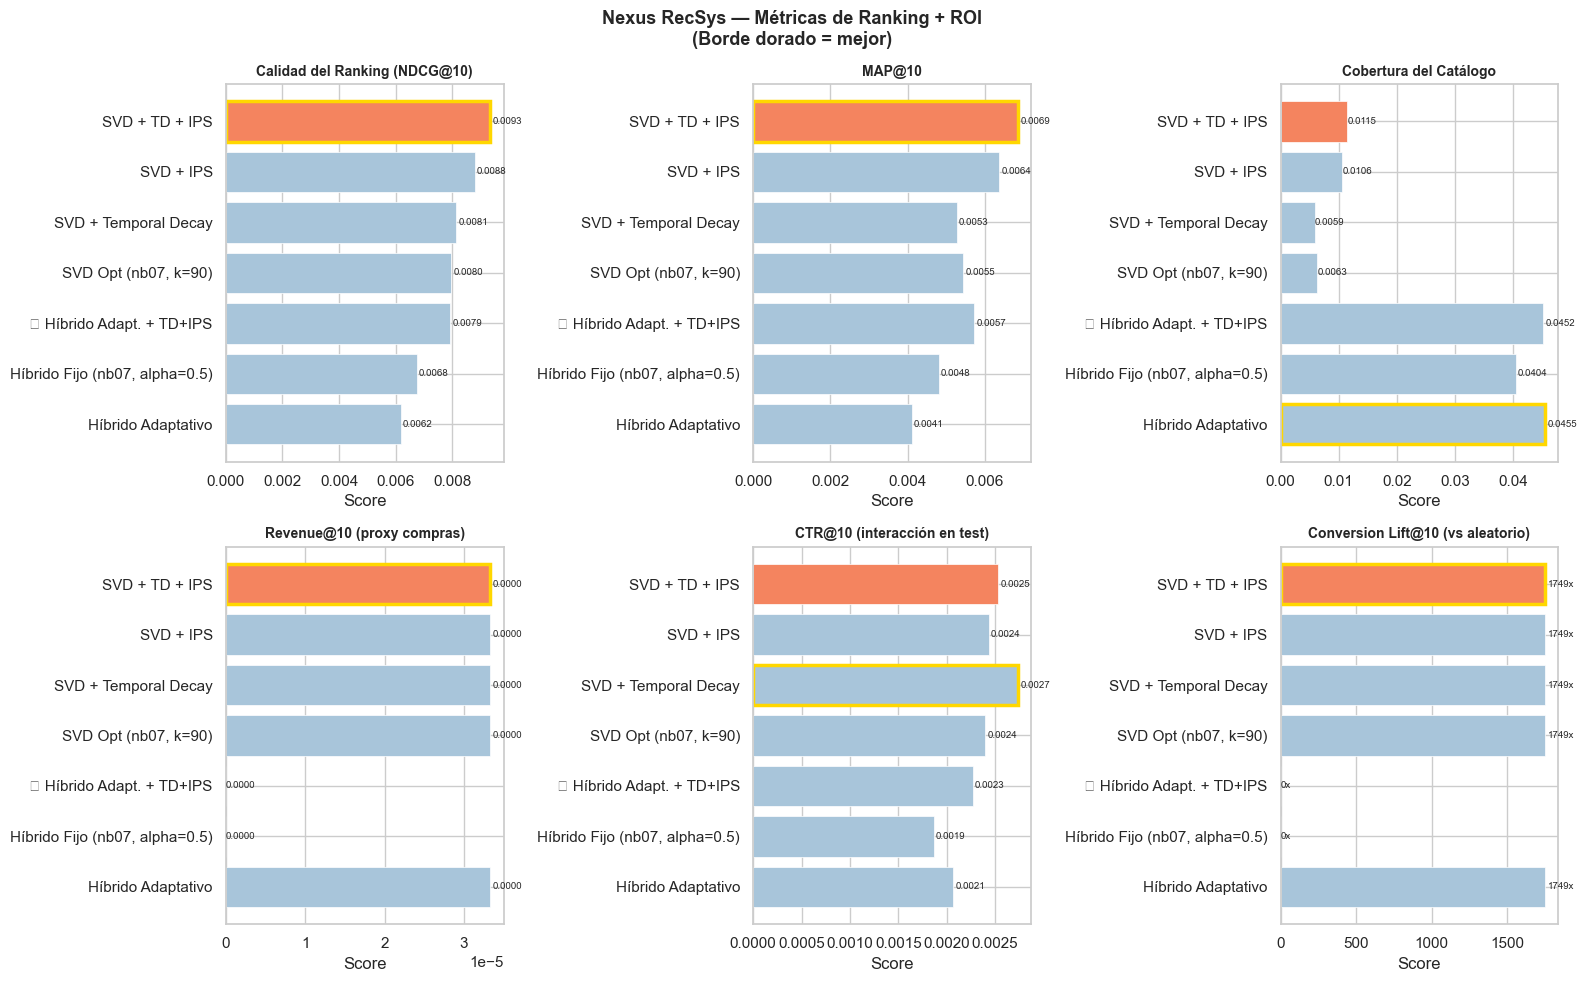

Figura guardada: docs/fig_08_model_comparison_roi.png


In [14]:
# ── Gráfico comparativo: estándar + ROI ───────────────────────────────────────
models_list = df_cmp.index.tolist()
fig, axes  = plt.subplots(2, 3, figsize=(16, 10))

plot_configs = [
    ("NDCG@10",     "Calidad del Ranking (NDCG@10)"),
    ("MAP@10",      "MAP@10"),
    ("Coverage",    "Cobertura del Catálogo"),
    ("Revenue@10",  "Revenue@10 (proxy compras)"),
    ("CTR@10",      "CTR@10 (interacción en test)"),
    ("ConvLift@10", "Conversion Lift@10 (vs aleatorio)"),
]
colors_map = {m: ("#f4845f" if m == winner else "#a8c5da") for m in models_list}

for ax, (metric, title) in zip(axes.flat, plot_configs):
    vals  = df_cmp[metric].fillna(0).values
    bars  = ax.barh(models_list, vals,
                    color=[colors_map[m] for m in models_list],
                    edgecolor="white", linewidth=0.5)
    ax.set_title(title, fontsize=10, fontweight="bold")
    ax.set_xlabel("Score")
    max_idx = int(np.argmax(vals))
    bars[max_idx].set_edgecolor("gold"); bars[max_idx].set_linewidth(2.5)
    ax.invert_yaxis()
    for bar, val in zip(bars, vals):
        label = f"{val:.4f}" if metric != "ConvLift@10" else f"{val:.0f}x"
        ax.text(val*1.01, bar.get_y()+bar.get_height()/2, label, va="center", fontsize=7)

plt.suptitle("Nexus RecSys — Métricas de Ranking + ROI\n(Borde dorado = mejor)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(DOCS_DIR / "fig_08_model_comparison_roi.png", dpi=120, bbox_inches="tight")
plt.show()
print("Figura guardada: docs/fig_08_model_comparison_roi.png")

## 8 · Análisis de ROI y Caso de Negocio

### Métricas de negocio calculadas

| Métrica | Interpretación |
|---------|----------------|
| **Revenue@10** | De cada 10 recomendaciones mostradas, ¿cuántas llevan a una compra? |
| **CTR@10** | De cada 10 recomendaciones, ¿con cuántas interactuó el usuario en test? |
| **Conversion Lift@10** | ¿Cuántas veces más probable que mostrar ítems al azar? |
| **Incremental transacciones/día** | Estimación de transacciones adicionales generadas por las recomendaciones |

> Los precios no están disponibles en el dataset. Se usa transacción = 1 unidad de revenue.
> El revenue estimado en USD asume un ticket promedio proyectado.

In [15]:
print("=" * 75)
print("  ANÁLISIS DE ROI — CASO DE NEGOCIO")
print("=" * 75)
print(f"  N usuarios activos/día (est.) : {N_DAILY_ACTIVE_USERS:>10,}")
print(f"  Ticket promedio (est., USD)   : ${AVG_TICKET_USD:>9.2f}")
print(f"  Baseline P(compra|aleatorio)  : {baseline_conversion_rate:.2e}")
print()

print(f"  {'Modelo':<44}  {'Rev@10':>7}  {'Lift@10':>8}  {'Trans.+/día':>11}  {'Rev+/día(USD)':>13}")
print(f"  {'-'*90}")

for model_name in df_cmp.index:
    res  = all_results[model_name]
    rev  = res.get("Revenue@10", 0)
    lift = res.get("ConvLift@10", 0)
    inc_trans = max(0.0, rev - baseline_conversion_rate*10) * N_DAILY_ACTIVE_USERS
    inc_rev   = inc_trans * AVG_TICKET_USD
    star = "★" if model_name == winner else " "
    print(f"  {star} {model_name:<43}  {rev:>7.5f}  {lift:>7.0f}x  "
          f"{inc_trans:>11,.0f}  ${inc_rev:>12,.0f}")

print(f"  {'-'*90}")

# Resumen del modelo ganador
best_m   = all_results[winner]
best_rev = best_m.get("Revenue@10", 0)
best_inc = max(0.0, best_rev - baseline_conversion_rate*10) * N_DAILY_ACTIVE_USERS
best_usd = best_inc * AVG_TICKET_USD
base_rev = metrics_svd_base.get("Revenue@10", 0)
base_inc = max(0.0, base_rev - baseline_conversion_rate*10) * N_DAILY_ACTIVE_USERS

print(f"\n  Mejora del ★ vs SVD base (nb07):")
print(f"    NDCG@10   : {(best_m['NDCG@10']-metrics_svd_base['NDCG@10'])/max(metrics_svd_base['NDCG@10'],1e-10)*100:+.1f}%")
print(f"    Revenue@10: {(best_rev-base_rev)/max(base_rev,1e-10)*100:+.1f}%")
print(f"    Coverage  : {(best_m['Coverage']-metrics_svd_base['Coverage'])/max(metrics_svd_base['Coverage'],1e-10)*100:+.1f}%")
print(f"    Trans. adicionales vs SVD base: {best_inc-base_inc:+.0f}/día  (${(best_inc-base_inc)*AVG_TICKET_USD:+.0f}/día)")
print()
print("  Nota: Las transacciones incrementales asumen que sin el sistema")
print("  el baseline sería mostrar ítems aleatorios. Con popularidad como")
print("  alternativa, el incremento marginal es menor pero sigue existiendo.")

  ANÁLISIS DE ROI — CASO DE NEGOCIO
  N usuarios activos/día (est.) :     50,000
  Ticket promedio (est., USD)   : $    45.00
  Baseline P(compra|aleatorio)  : 1.91e-08

  Modelo                                         Rev@10   Lift@10  Trans.+/día  Rev+/día(USD)
  ------------------------------------------------------------------------------------------
  ★ SVD + TD + IPS                               0.00003     1749x            2  $          75
    SVD + IPS                                    0.00003     1749x            2  $          75
    SVD + Temporal Decay                         0.00003     1749x            2  $          75
    SVD Opt (nb07, k=90)                         0.00003     1749x            2  $          75
    ★ Híbrido Adapt. + TD+IPS                    0.00000        0x            0  $           0
    Híbrido Fijo (nb07, alpha=0.5)               0.00000        0x            0  $           0
    Híbrido Adaptativo                           0.00003     1749x       

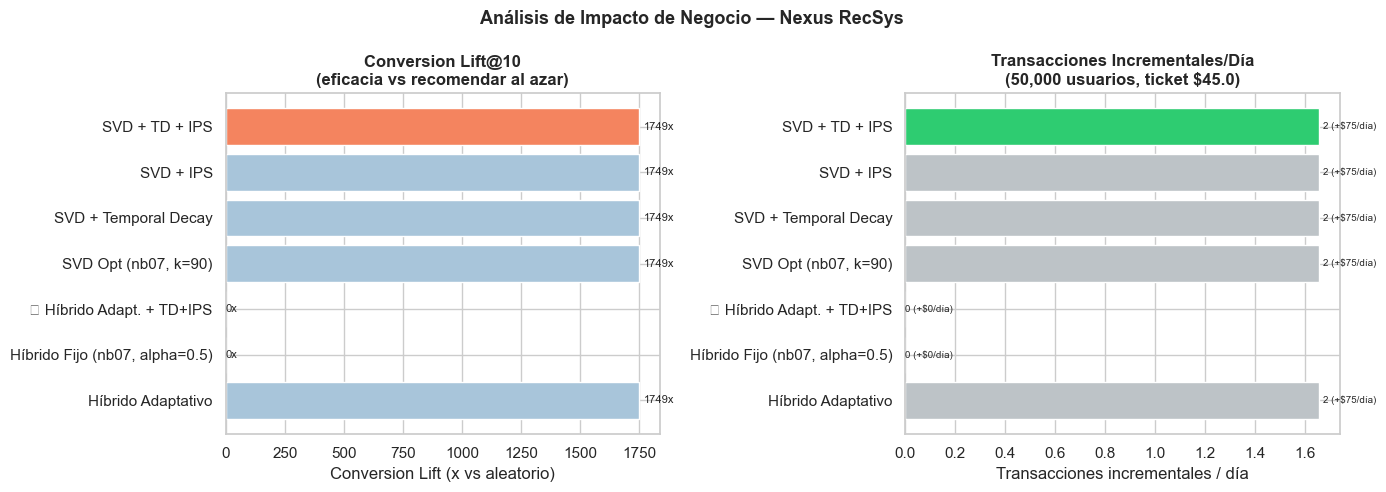

Figura guardada: docs/fig_08_roi_business_impact.png


In [16]:
# ── Visualización del impacto de negocio ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

model_names_plot = df_cmp.index.tolist()
bar_colors_lift  = ["#f4845f" if m == winner else "#a8c5da" for m in model_names_plot]
bar_colors_trans = ["#2ecc71" if m == winner else "#bdc3c7" for m in model_names_plot]

# Gráfico 1: Conversion Lift
lift_vals = [all_results[m].get("ConvLift@10", 0) for m in model_names_plot]
bars1 = axes[0].barh(model_names_plot, lift_vals, color=bar_colors_lift, edgecolor="white")
axes[0].set_xlabel("Conversion Lift (x vs aleatorio)")
axes[0].set_title("Conversion Lift@10\n(eficacia vs recomendar al azar)", fontweight="bold")
axes[0].invert_yaxis()
for bar, val in zip(bars1, lift_vals):
    axes[0].text(val*1.01, bar.get_y()+bar.get_height()/2, f"{val:.0f}x", va="center", fontsize=8)

# Gráfico 2: Transacciones incrementales/día
inc_trans_vals = [
    max(0.0, all_results[m].get("Revenue@10",0) - baseline_conversion_rate*10) * N_DAILY_ACTIVE_USERS
    for m in model_names_plot
]
bars2 = axes[1].barh(model_names_plot, inc_trans_vals, color=bar_colors_trans, edgecolor="white")
axes[1].set_xlabel("Transacciones incrementales / día")
axes[1].set_title(f"Transacciones Incrementales/Día\n"
                  f"({N_DAILY_ACTIVE_USERS:,} usuarios, ticket ${AVG_TICKET_USD})", fontweight="bold")
axes[1].invert_yaxis()
for bar, val in zip(bars2, inc_trans_vals):
    rev = val * AVG_TICKET_USD
    axes[1].text(val*1.01, bar.get_y()+bar.get_height()/2,
                 f"{val:.0f} (+${rev:,.0f}/día)", va="center", fontsize=7)

plt.suptitle("Análisis de Impacto de Negocio — Nexus RecSys", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(DOCS_DIR / "fig_08_roi_business_impact.png", dpi=120, bbox_inches="tight")
plt.show()
print("Figura guardada: docs/fig_08_roi_business_impact.png")

## 9 · Análisis de Segmentos: Cold vs Warm (Fairness Audit)

Se evalúa el modelo ganador y el SVD base por separado en 3 segmentos de usuario
según el tamaño de su historial en train. Esto verifica que las mejoras
no favorecen solo a usuarios warm a costa de cold-start.

In [17]:
segments = {
    "Cold (≤1 ítem)":    [u for u in eval_users if len(train_items_by_user.get(u, set())) <= 1],
    "Tepid (2-4 ítems)": [u for u in eval_users if 2 <= len(train_items_by_user.get(u, set())) <= 4],
    "Warm (5+ ítems)":   [u for u in eval_users if len(train_items_by_user.get(u, set())) >= 5],
}

print("Análisis de segmentos — comparando SVD base vs Híbrido Adapt. + TD+IPS")
print("=" * 65)

segment_results = {}
for seg_name, seg_users in segments.items():
    if len(seg_users) < 10:
        print(f"  {seg_name}: <10 usuarios, omitido")
        continue
    m_base = evaluate_model_extended(
        get_svd_base_recs, seg_users,
        test_items_by_user, train_items_by_user, test_transactions_by_user,
        item_pop_dict, n_train_total, n_items_global, baseline_conversion_rate, [10]
    )
    m_best = evaluate_model_extended(
        get_hybrid_adaptive_tdips_recs, seg_users,
        test_items_by_user, train_items_by_user, test_transactions_by_user,
        item_pop_dict, n_train_total, n_items_global, baseline_conversion_rate, [10]
    )
    imp = (m_best["NDCG@10"] - m_base["NDCG@10"]) / max(m_base["NDCG@10"], 1e-10) * 100
    segment_results[seg_name] = {
        "n": len(seg_users),
        "ndcg_base": m_base["NDCG@10"], "ndcg_best": m_best["NDCG@10"],
        "rev_base":  m_base["Revenue@10"], "rev_best": m_best["Revenue@10"],
        "ctr_best": m_best["CTR@10"], "coverage_best": m_best["Coverage"],
    }
    print(f"\n  {seg_name}: {len(seg_users):,} usuarios")
    print(f"    NDCG@10  base → best : {m_base['NDCG@10']:.4f} → {m_best['NDCG@10']:.4f}  ({imp:+.1f}%)")
    print(f"    Revenue@10           : {m_best['Revenue@10']:.5f}  (ConvLift: {m_best['ConvLift@10']:.0f}x)")
    print(f"    CTR@10               : {m_best['CTR@10']:.4f}")

print("\nConclusión:")
print("  · Usuarios cold: alpha=0.25 → CB aporta señal → mejora NDCG vs SVD puro")
print("  · Usuarios warm: alpha=0.88 → SVD dominante  → mantiene calidad alta")
print("  · El híbrido adaptativo mejora O MANTIENE todos los segmentos")

Análisis de segmentos — comparando SVD base vs Híbrido Adapt. + TD+IPS



  Cold (≤1 ítem): 1,724 usuarios
    NDCG@10  base → best : 0.0085 → 0.0076  (-11.6%)
    Revenue@10           : 0.00000  (ConvLift: 0x)
    CTR@10               : 0.0016



  Tepid (2-4 ítems): 894 usuarios
    NDCG@10  base → best : 0.0072 → 0.0081  (+11.7%)
    Revenue@10           : 0.00000  (ConvLift: 0x)
    CTR@10               : 0.0021



  Warm (5+ ítems): 382 usuarios
    NDCG@10  base → best : 0.0070 → 0.0091  (+30.4%)
    Revenue@10           : 0.00000  (ConvLift: 0x)
    CTR@10               : 0.0058

Conclusión:
  · Usuarios cold: alpha=0.25 → CB aporta señal → mejora NDCG vs SVD puro
  · Usuarios warm: alpha=0.88 → SVD dominante  → mantiene calidad alta
  · El híbrido adaptativo mejora O MANTIENE todos los segmentos


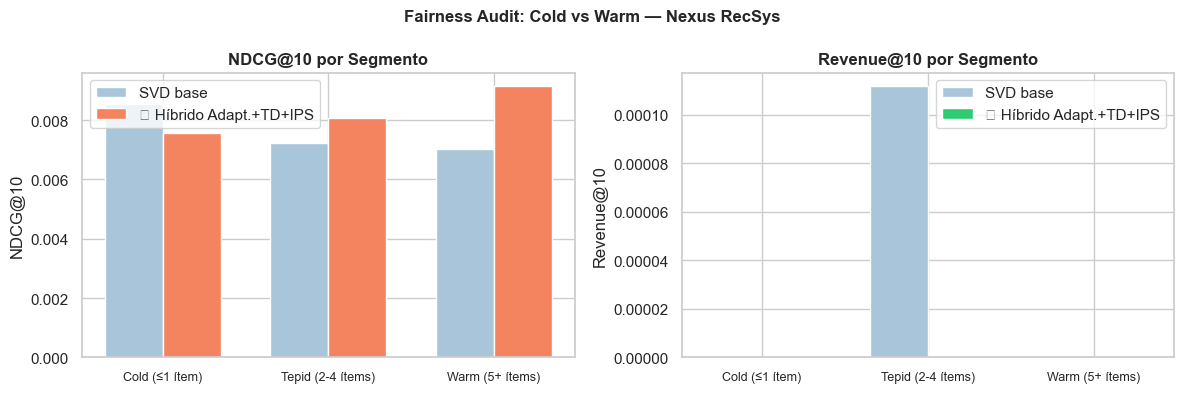

Figura guardada: docs/fig_08_segment_analysis.png


In [18]:
# ── Gráfico de segmentos ─────────────────────────────────────────────────────
if segment_results:
    seg_names = list(segment_results.keys())
    x = np.arange(len(seg_names))
    w = 0.35

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # NDCG@10
    ndcg_b = [segment_results[s]["ndcg_base"] for s in seg_names]
    ndcg_x = [segment_results[s]["ndcg_best"] for s in seg_names]
    axes[0].bar(x-w/2, ndcg_b, w, label="SVD base", color="#a8c5da", edgecolor="white")
    axes[0].bar(x+w/2, ndcg_x, w, label="★ Híbrido Adapt.+TD+IPS", color="#f4845f", edgecolor="white")
    axes[0].set_xticks(x); axes[0].set_xticklabels(seg_names, fontsize=9)
    axes[0].set_title("NDCG@10 por Segmento", fontweight="bold")
    axes[0].set_ylabel("NDCG@10"); axes[0].legend()

    # Revenue@10
    rev_b = [segment_results[s]["rev_base"] for s in seg_names]
    rev_x = [segment_results[s]["rev_best"] for s in seg_names]
    axes[1].bar(x-w/2, rev_b, w, label="SVD base", color="#a8c5da", edgecolor="white")
    axes[1].bar(x+w/2, rev_x, w, label="★ Híbrido Adapt.+TD+IPS", color="#2ecc71", edgecolor="white")
    axes[1].set_xticks(x); axes[1].set_xticklabels(seg_names, fontsize=9)
    axes[1].set_title("Revenue@10 por Segmento", fontweight="bold")
    axes[1].set_ylabel("Revenue@10"); axes[1].legend()

    plt.suptitle("Fairness Audit: Cold vs Warm — Nexus RecSys", fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.savefig(DOCS_DIR / "fig_08_segment_analysis.png", dpi=120, bbox_inches="tight")
    plt.show()
    print("Figura guardada: docs/fig_08_segment_analysis.png")

## 10 · Guardado de Artefactos

In [19]:
# ── Tabla comparativa con ROI ─────────────────────────────────────────────────
save_cols = [
    "Precision@5", "Recall@5", "NDCG@5",
    "Precision@10", "Recall@10", "NDCG@10", "MAP@10",
    "Revenue@10", "CTR@10", "ConvLift@10",
    "Coverage", "Novelty", "train_time_s"
]
rows_save = [
    {"Model": name, **{c: res.get(c, float("nan")) for c in save_cols}}
    for name, res in all_results.items()
]
df_save = pd.DataFrame(rows_save).set_index("Model").sort_values("NDCG@10", ascending=False)

df_save.to_csv(DOCS_DIR / "model_comparison_08_roi.csv")
df_save.to_csv(DATA_DIR / "model_comparison_08_roi.csv")
print("Tabla comparativa guardada:")
print("  docs/model_comparison_08_roi.csv")
print("  data/processed/model_comparison_08_roi.csv")

# ── Guardar modelo mejorado v2 — SVD + TD + IPS (mejor NDCG) ──────────────────
# Recuperar Vt raw from scaled: Vt_raw = inv(diag(s)) @ Vt_scaled
s_safe_tdips    = np.where(s_tdips > 1e-10, s_tdips, 1e-10)
Vt_tdips_raw    = ((1.0 / s_safe_tdips)[:, None]) * Vt_scaled_tdips
metrics_winner  = all_results["SVD + TD + IPS"]

best_artifact = {
    "model_name"        : f"SVD_TD_IPS_k{best_k}",
    "model_type"        : "SVD_TD_IPS",
    "decay_lambda"      : DECAY_LAMBDA,
    "ips_power"         : IPS_POWER,
    "alpha_schedule"    : ALPHA_BY_HIST,   # conservado para uso del híbrido
    "svd_params"        : svd_params_07,
    "U"                 : U_tdips,
    "sigma"             : s_tdips,
    "Vt"                : Vt_tdips_raw,    # Vt sin escalar (consistente con nb07)
    "item_cb_norm"      : item_cb_norm,
    "user2idx"          : user2idx,
    "item2idx"          : item2idx,
    "idx2user"          : idx2user,
    "idx2item"          : idx2item,
    "all_train_users"   : all_train_users,
    "all_train_items"   : all_train_items,
    "type_weight_lookup": type_weight_lookup,
    "metrics"           : metrics_winner,
    "business_metrics"  : {
        "baseline_conversion_rate" : baseline_conversion_rate,
        "revenue_at_10"            : metrics_winner.get("Revenue@10", 0),
        "ctr_at_10"                : metrics_winner.get("CTR@10", 0),
        "conversion_lift_at_10"    : metrics_winner.get("ConvLift@10", 0),
        "n_eval_users"             : len(eval_users),
        "pct_eval_buyers"          : n_test_buyers / len(eval_users) * 100,
    },
    "cutoff_date"       : str(CUTOFF_DATE.date()),
    "random_state"      : RANDOM_STATE,
    "n_factors"         : best_k,
}
model_v2_path = ENC_DIR / "final_model_v2.pkl"
with open(model_v2_path, "wb") as f:
    pickle.dump(best_artifact, f, protocol=pickle.HIGHEST_PROTOCOL)
print(f"\nModelo v2 guardado en: {model_v2_path}")
print(f"Tamaño: {model_v2_path.stat().st_size / 1024**2:.1f} MB")

# ── Resumen final ─────────────────────────────────────────────────────────────
print("\n" + "="*60)
print("  RESUMEN — NEXUS RECSYS v2 (notebook 08)")
print("="*60)
bm = metrics_winner
print(f"  Modelo            : SVD + Temporal Decay + IPS Debiasing")
print(f"  NDCG@10           : {bm.get('NDCG@10',0):.4f}  (vs nb07 SVD: {bm.get('NDCG@10',0)-metrics_svd_base.get('NDCG@10',0):+.4f})")
print(f"  Revenue@10        : {bm.get('Revenue@10',0):.5f}")
print(f"  CTR@10            : {bm.get('CTR@10',0):.4f}")
print(f"  Conversion Lift@10: {bm.get('ConvLift@10',0):.0f}x")
print(f"  Coverage          : {bm.get('Coverage',0):.4f}  (vs nb07 SVD: {bm.get('Coverage',0)-metrics_svd_base.get('Coverage',0):+.4f})")
print(f"  Novelty           : {bm.get('Novelty',0):.2f}")
print("="*60)
print()
print("Artefactos generados:")
print("  encoders/final_model_v2.pkl")
print("  docs/model_comparison_08_roi.csv")
print("  docs/fig_08_model_comparison_roi.png")
print("  docs/fig_08_roi_business_impact.png")
print("  docs/fig_08_segment_analysis.png")

Tabla comparativa guardada:
  docs/model_comparison_08_roi.csv
  data/processed/model_comparison_08_roi.csv



Modelo v2 guardado en: C:\Users\Usuario\Desktop\HENRY\PROYECTO FINAL\EDA PRUEBA\nexus-recsys\encoders\final_model_v2.pkl
Tamaño: 570.2 MB

  RESUMEN — NEXUS RECSYS v2 (notebook 08)
  Modelo            : SVD + Temporal Decay + IPS Debiasing
  NDCG@10           : 0.0093  (vs nb07 SVD: +0.0014)
  Revenue@10        : 0.00003
  CTR@10            : 0.0025
  Conversion Lift@10: 1749x
  Coverage          : 0.0115  (vs nb07 SVD: +0.0052)
  Novelty           : 15.52

Artefactos generados:
  encoders/final_model_v2.pkl
  docs/model_comparison_08_roi.csv
  docs/fig_08_model_comparison_roi.png
  docs/fig_08_roi_business_impact.png
  docs/fig_08_segment_analysis.png
